# 06 — QAOA narrative: exact scaling + depth scan

**NON_BASELINE_RUN / NON_FINAL_CONFIG.** Không tuyên bố quantum advantage.

Notebook này trả lời hai câu hỏi trình bày cho cuộc thi:

1. **Exact có tường không?** — đo runtime exact theo số bit \(n\) (đường cong \(O(2^n)\)).
2. **QAOA có cải thiện theo độ sâu \(p\) không?** — quét \(p=1,2\) trên stress-instance 10-bit, **không warm-start**.

Không trộn số ở đây với true-CVaR baseline `workflow_update` 20-bit. Artifact ghi vào `artifacts_bench/narrative_run/`.

In [1]:
from __future__ import annotations

import json
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from qshield_quantum.benchmark import coordinate_descent_classical
from qshield_quantum.formulation.qiskit_program import build_quadratic_program
from qshield_quantum.formulation.surrogate import QuadraticSurrogate
from qshield_quantum.solvers.exact import solve_quadratic_exact
from qshield_quantum.solvers.qaoa import solve_qaoa_one_seed

ROOT = Path.cwd().resolve()
while not (ROOT / "CLAUDE.md").exists():
    ROOT = ROOT.parent

OUT = ROOT / "artifacts_bench" / "narrative_run"
OUT.mkdir(parents=True, exist_ok=True)
REAL_QUBO = ROOT / "artifacts_bench" / "warm_start_run" / "qubo_model.json"
print("ROOT=", ROOT)
print("OUT=", OUT)

Matplotlib is building the font cache; this may take a moment.


ROOT= /Users/mac/Documents/QSHIELD
OUT= /Users/mac/Documents/QSHIELD/artifacts_bench/narrative_run


## Helpers — stress QUBO sibling (cùng tinh thần `tools/qaoa_stress_bakeoff.py`)

In [2]:
def real_linear_scale() -> float:
    if not REAL_QUBO.exists():
        return 0.023
    linear = np.asarray(json.loads(REAL_QUBO.read_text())["linear"], dtype=float)
    return float(np.mean(np.abs(linear)))


def build_stress(n: int, *, seed: int = 20260807) -> QuadraticSurrogate:
    """Frustrated n-bit QUBO: mixed linear, strong Q, soft prefer weight ≈ n/2."""
    scale = real_linear_scale()
    rng = np.random.default_rng(seed + n)
    linear = rng.normal(0.0, scale, size=n)
    Q = rng.normal(0.0, scale * 0.4, size=(n, n))
    Q = 0.5 * (Q + Q.T)
    np.fill_diagonal(Q, 0.0)
    k = n // 2
    penalty = scale * 3.0
    constant = penalty * (k**2)
    linear = linear + penalty * (1.0 - 2.0 * k)
    for i in range(n):
        for j in range(i + 1, n):
            Q[i, j] += penalty
            Q[j, i] += penalty
    return QuadraticSurrogate(
        Q=Q,
        linear=linear,
        constant=float(constant),
        residual_sum_squares=0.0,
        rank=n,
        sample_count=0,
    )


def gap(energy: float, opt: float) -> float:
    if opt == 0:
        return float("nan")
    return (energy - opt) / abs(opt)


print("linear_scale_from_real=", real_linear_scale())

linear_scale_from_real= 0.023742373014302834


## Phần 1 — Exact scaling \(O(2^n)\)

Đo runtime exact (+ classical mạnh làm đối chiếu) trên stress QUBO từ \(n=8\) đến \(n=16\).
Đây là lập luận chính: **exact có tường**, dù hôm nay 20-bit production vẫn chạy được.

In [3]:
NS = [8, 10, 12, 14, 16]
scale_rows = []

for n in NS:
    model = build_stress(n)
    t0 = time.perf_counter()
    exact = solve_quadratic_exact(model, feasibility=None, top_n=5)
    exact_s = time.perf_counter() - t0

    t0 = time.perf_counter()
    c_bits, c_e = coordinate_descent_classical(
        model, feasibility=None, restarts=64, seed=0
    )
    classical_s = time.perf_counter() - t0

    row = {
        "n": n,
        "states": 1 << n,
        "exact_runtime_s": exact_s,
        "classical_runtime_s": classical_s,
        "exact_bitstring": exact.best_feasible_bitstring,
        "exact_energy": exact.best_feasible_energy,
        "classical_bitstring": c_bits,
        "classical_energy": float(c_e),
        "classical_gap": gap(float(c_e), exact.best_feasible_energy),
        "classical_matches_exact": c_bits == exact.best_feasible_bitstring,
    }
    scale_rows.append(row)
    print(
        f"n={n:2d} states={1 << n:7d}  exact={exact_s:8.4f}s  "
        f"classical={classical_s:8.4f}s  match={row['classical_matches_exact']}",
        flush=True,
    )

scale_df = pd.DataFrame(scale_rows)
scale_df

n= 8 states=    256  exact=  0.0018s  classical=  0.0059s  match=True


n=10 states=   1024  exact=  0.0027s  classical=  0.0063s  match=True


n=12 states=   4096  exact=  0.0113s  classical=  0.0080s  match=True


n=14 states=  16384  exact=  0.0509s  classical=  0.0128s  match=True


n=16 states=  65536  exact=  0.2232s  classical=  0.0114s  match=True


,n,states,exact_runtime_s,classical_runtime_s,exact_bitstring,exact_energy,classical_bitstring,classical_energy,classical_gap,classical_matches_exact
0,8,256,0.001779,0.005881,10000111,-0.175398,10000111,-0.175398,0.000000e+00,True
1,10,1024,0.002664,0.006316,1001011100,-0.145845,1001011100,-0.145845,0.000000e+00,True
2,12,4096,0.011330,0.007959,010011101010,-0.189708,010011101010,-0.189708,-2.340908e-15,True
3,14,16384,0.050893,0.012837,01010110000111,-0.254702,01010110000111,-0.254702,-5.230700e-15,True
4,16,65536,0.223169,0.011381,1001001001110011,-0.247757,1001001001110011,-0.247757,0.000000e+00,True


wrote /Users/mac/Documents/QSHIELD/artifacts_bench/narrative_run/exact_scaling.png


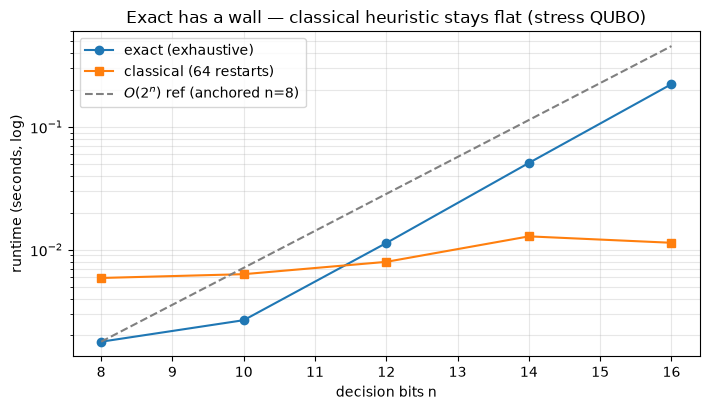

In [4]:
fig, ax = plt.subplots(figsize=(7.2, 4.2))
ax.semilogy(
    scale_df["n"], scale_df["exact_runtime_s"], "o-", label="exact (exhaustive)"
)
ax.semilogy(
    scale_df["n"],
    scale_df["classical_runtime_s"],
    "s-",
    label="classical (64 restarts)",
)
# Reference O(2^n) line anchored at n=8
ref0 = float(scale_df.loc[scale_df["n"] == 8, "exact_runtime_s"].iloc[0])
ref_n = np.asarray(NS, dtype=float)
ax.semilogy(
    ref_n,
    ref0 * (2 ** (ref_n - 8)),
    "--",
    color="gray",
    label=r"$O(2^n)$ ref (anchored n=8)",
)
ax.set_xlabel("decision bits n")
ax.set_ylabel("runtime (seconds, log)")
ax.set_title("Exact has a wall — classical heuristic stays flat (stress QUBO)")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
fig.tight_layout()
fig_path = OUT / "exact_scaling.png"
fig.savefig(fig_path, dpi=140)
print("wrote", fig_path)
plt.show()

## Phần 2 — Quét độ sâu QAOA \(p=1,2\) trên stress 10-bit

- **Không warm-start** (phép thử trung thực).
- 1 seed, shots=128, maxiter=20 — `NON_FINAL` smoke để notebook chạy được trong buổi.
- So với exact + classical trên **cùng** stress model.

Kỳ vọng trung thực: chất lượng có thể cải thiện theo \(p\), nhưng runtime simulator tăng; classical vẫn rất mạnh ở n=10.

In [5]:
N_P = 10
SEED = 101
SHOTS = 128
MAXITER = 20
PS = [1, 2]

model_p = build_stress(N_P, seed=20260807)
names = [f"b{i}" for i in range(N_P)]
qp = build_quadratic_program(
    model_p.Q, model_p.linear, model_p.constant, ticker_order=names
)

t0 = time.perf_counter()
exact_p = solve_quadratic_exact(model_p, feasibility=None, top_n=5)
exact_p_s = time.perf_counter() - t0
opt_e = exact_p.best_feasible_energy
opt_bits = exact_p.best_feasible_bitstring

t0 = time.perf_counter()
c_bits, c_e = coordinate_descent_classical(model_p, restarts=64, seed=0)
classical_p_s = time.perf_counter() - t0

print(f"exact opt={opt_bits} E={opt_e:.6f} ({exact_p_s:.4f}s)")
print(
    f"classical={c_bits} E={c_e:.6f} gap={gap(c_e, opt_e):.4%} ({classical_p_s:.4f}s)"
)

exact opt=1001011100 E=-0.145845 (0.0028s)
classical=1001011100 E=-0.145845 gap=0.0000% (0.0065s)


In [6]:
p_rows = []
for p in PS:
    print(
        f"\n=== QAOA p={p} seed={SEED} shots={SHOTS} maxiter={MAXITER} no-warm-start ===",
        flush=True,
    )
    result = solve_qaoa_one_seed(
        qp,
        seed=SEED,
        shots=SHOTS,
        maxiter=MAXITER,
        feasibility=lambda _z: True,
        reference_bitstring=opt_bits,
        reps=p,
        warm_start=False,
        candidate_pool_size=20,
    )
    row = {
        "p": p,
        "seed": SEED,
        "shots": SHOTS,
        "maxiter": MAXITER,
        "warm_start": False,
        "bitstring": result.bitstring,
        "energy": float(result.energy),
        "optimality_gap": gap(float(result.energy), opt_e),
        "matches_exact": result.bitstring == opt_bits,
        "success_prob": float(result.success_prob),
        "runtime_s": float(result.runtime_seconds),
    }
    p_rows.append(row)
    print(
        f"p={p} bits={result.bitstring} E={result.energy:.6f} "
        f"gap={row['optimality_gap']:.4%} success_p={result.success_prob:.4g} "
        f"runtime={result.runtime_seconds:.2f}s",
        flush=True,
    )

p_df = pd.DataFrame(p_rows)
p_df


=== QAOA p=1 seed=101 shots=128 maxiter=20 no-warm-start ===


/Users/mac/Documents/QSHIELD/.venv/lib/python3.14/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:653: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/Users/mac/Documents/QSHIELD/.venv/lib/python3.14/site-packages/scipy/sparse/linalg/_matfuncs.py:706: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)
/Users/mac/Documents/QSHIELD/.venv/lib/python3.14/site-packages/scipy/sparse/_index.py:174: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


p=1 bits=1011101000 E=-0.118996 gap=18.4093% success_p=0 runtime=251.47s



=== QAOA p=2 seed=101 shots=128 maxiter=20 no-warm-start ===


/Users/mac/Documents/QSHIELD/.venv/lib/python3.14/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:653: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/Users/mac/Documents/QSHIELD/.venv/lib/python3.14/site-packages/scipy/sparse/linalg/_matfuncs.py:706: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)


p=2 bits=1011001100 E=-0.122025 gap=16.3328% success_p=0 runtime=496.40s


,p,seed,shots,maxiter,warm_start,bitstring,energy,optimality_gap,matches_exact,success_prob,runtime_s
0,1,101,128,20,False,1011101000,-0.118996,0.184093,False,0.0,251.470137
1,2,101,128,20,False,1011001100,-0.122025,0.163328,False,0.0,496.401527


wrote /Users/mac/Documents/QSHIELD/artifacts_bench/narrative_run/qaoa_depth_scan.png


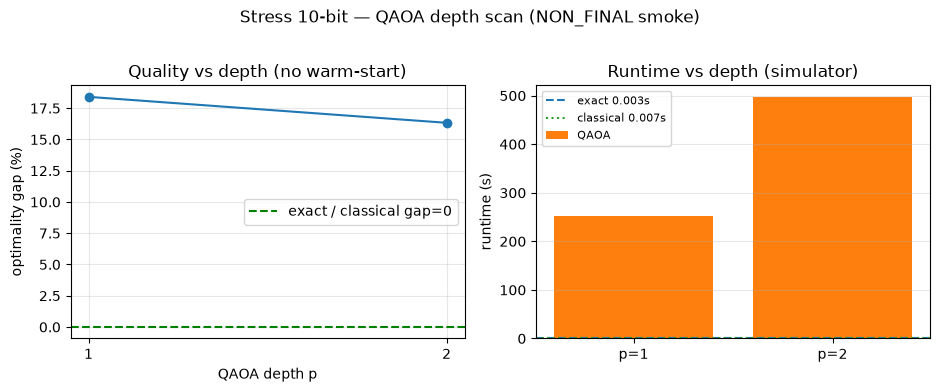

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.8))

ax = axes[0]
ax.plot(p_df["p"], p_df["optimality_gap"] * 100, "o-", color="C0")
ax.axhline(0.0, color="green", ls="--", label="exact / classical gap=0")
ax.set_xlabel("QAOA depth p")
ax.set_ylabel("optimality gap (%)")
ax.set_title("Quality vs depth (no warm-start)")
ax.set_xticks(PS)
ax.grid(True, alpha=0.3)
ax.legend()

ax = axes[1]
ax.bar([f"p={p}" for p in p_df["p"]], p_df["runtime_s"], color="C1", label="QAOA")
ax.axhline(exact_p_s, color="C0", ls="--", label=f"exact {exact_p_s:.3f}s")
ax.axhline(classical_p_s, color="C2", ls=":", label=f"classical {classical_p_s:.3f}s")
ax.set_ylabel("runtime (s)")
ax.set_title("Runtime vs depth (simulator)")
ax.legend(fontsize=8)
ax.grid(True, axis="y", alpha=0.3)

fig.suptitle("Stress 10-bit — QAOA depth scan (NON_FINAL smoke)", y=1.02)
fig.tight_layout()
fig_path = OUT / "qaoa_depth_scan.png"
fig.savefig(fig_path, dpi=140, bbox_inches="tight")
print("wrote", fig_path)
plt.show()

## Kết luận notebook (để đưa vào slide)

In [8]:
payload = {
    "status": "NON_BASELINE_RUN",
    "NON_FINAL_CONFIG": True,
    "disclaimer": (
        "Narrative bakeoff only. Not workflow_update true-CVaR evidence. "
        "No quantum-advantage claim (StatevectorSampler)."
    ),
    "exact_scaling": scale_rows,
    "depth_scan": {
        "n": N_P,
        "shots": SHOTS,
        "maxiter": MAXITER,
        "seed": SEED,
        "warm_start": False,
        "exact": {
            "bitstring": opt_bits,
            "energy": opt_e,
            "runtime_s": exact_p_s,
        },
        "classical": {
            "bitstring": c_bits,
            "energy": float(c_e),
            "runtime_s": classical_p_s,
            "gap": gap(float(c_e), opt_e),
        },
        "qaoa_by_p": p_rows,
    },
}
out_json = OUT / "narrative_bakeoff.json"
out_json.write_text(json.dumps(payload, indent=2))
print("wrote", out_json)

print("\n=== SLIDE LINES ===")
print("1) Exact runtime grows ~2^n on stress QUBO; classical stays ~ms–tens of ms.")
last = scale_df.iloc[-1]
first = scale_df.iloc[0]
print(
    f"   n={int(first['n'])}→{int(last['n'])}: exact "
    f"{first['exact_runtime_s']:.4f}s → {last['exact_runtime_s']:.4f}s "
    f"(×{last['exact_runtime_s'] / max(first['exact_runtime_s'], 1e-12):.0f})"
)
print("2) QAOA depth scan (no warm-start) on stress 10-bit:")
for r in p_rows:
    print(
        f"   p={r['p']}: gap={r['optimality_gap']:.2%}  "
        f"match_exact={r['matches_exact']}  runtime={r['runtime_s']:.1f}s"
    )
print("3) Classical matches exact here and is orders of magnitude faster on simulator.")
print(
    "4) Honest claim: we know WHEN classical/exact hit a wall; QAOA is the candidate path beyond it — not a win today."
)

wrote /Users/mac/Documents/QSHIELD/artifacts_bench/narrative_run/narrative_bakeoff.json

=== SLIDE LINES ===
1) Exact runtime grows ~2^n on stress QUBO; classical stays ~ms–tens of ms.
   n=8→16: exact 0.0018s → 0.2232s (×125)
2) QAOA depth scan (no warm-start) on stress 10-bit:
   p=1: gap=18.41%  match_exact=False  runtime=251.5s
   p=2: gap=16.33%  match_exact=False  runtime=496.4s
3) Classical matches exact here and is orders of magnitude faster on simulator.
4) Honest claim: we know WHEN classical/exact hit a wall; QAOA is the candidate path beyond it — not a win today.
